# Plant Disease Detection using CNN

Dataset: PlantVillage (Kaggle) - 38 classes, ~54,000 leaf images

Pipeline:
1. EDA
2. Data Preprocessing
3. Baseline CNN
4. Improved CNN (BatchNorm, Dropout, L2)
5. Transfer Learning (MobileNetV2, EfficientNetB0)
6. Fine-Tuning
7. Grad-CAM Explainability
8. Model Comparison

# Imports & Configuration

In [ ]:
!pip install -q kaggle

In [ ]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 17.5 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "joyturi1234"                         # Your kaggle Username
os.environ["KAGGLE_KEY"] = "KGAT_cd2e6f82d635fec55c620ffe0t8c2287"    # Kaggle API key

In [ ]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:23<00:00, 93.7MB/s]



In [ ]:
!unzip -q plantvillage-dataset.zip -d /content/plantvillage

In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
DATA_DIR = "/content/plantvillage/plantvillage dataset/color"
IMG_SIZE = 160
BATCH_SIZE = 32
EPOCHS = 10

CLASS_NAMES = sorted(os.listdir(DATA_DIR))
NUM_CLASSES = len(CLASS_NAMES)

# EDA

In [ ]:
class_counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in CLASS_NAMES}
counts_df = pd.DataFrame(class_counts.items(), columns=["Class", "Count"]).sort_values("Count")

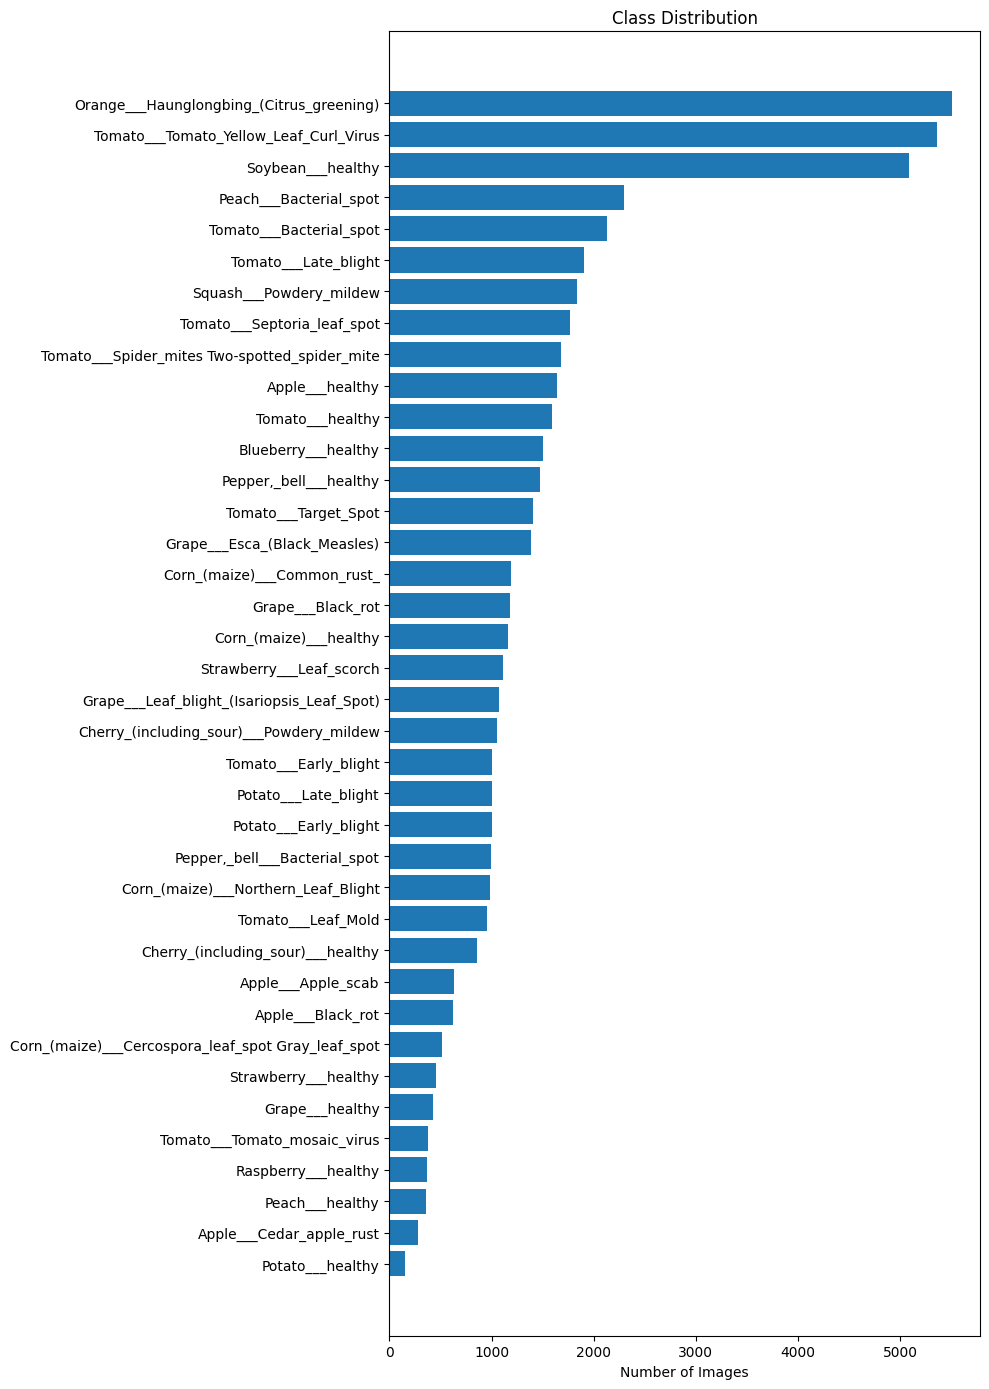

In [ ]:
plt.figure(figsize=(10, 14))
plt.barh(counts_df["Class"], counts_df["Count"])
plt.xlabel("Number of Images")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

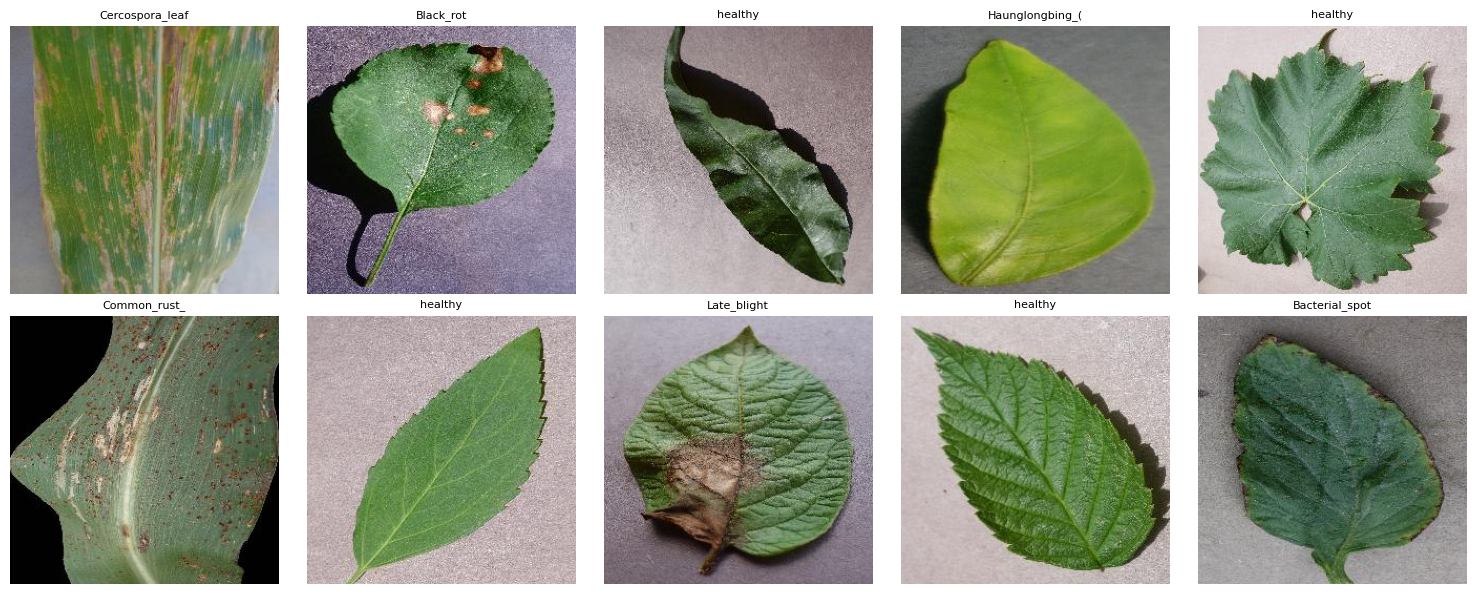

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_classes = random.sample(CLASS_NAMES, 10)

for ax, cls in zip(axes.flat, sample_classes):
    img_name = random.choice(os.listdir(os.path.join(DATA_DIR, cls)))
    img = Image.open(os.path.join(DATA_DIR, cls, img_name))
    ax.imshow(img)
    ax.set_title(cls.split("___")[-1][:15], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
sample_img = Image.open(os.path.join(DATA_DIR, CLASS_NAMES[0], os.listdir(os.path.join(DATA_DIR, CLASS_NAMES[0]))[0]))
print("Sample image size:", sample_img.size)
print("Max class count:", counts_df["Count"].max())
print("Min class count:", counts_df["Count"].min())
print("Imbalance ratio:", round(counts_df["Count"].max() / counts_df["Count"].min(), 2))

Sample image size: (256, 256)
Max class count: 5507
Min class count: 152
Imbalance ratio: 36.23


# Data Preprocessing

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

In [ ]:
val_gen = val_datagen.flow_from_directory(
    DATA_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

In [ ]:
class_indices = train_gen.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [ ]:
results = {}

def evaluate_model(model, name):
    val_gen.reset()
    preds = model.predict(val_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_gen.classes

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

    print(f"{name} -> Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")
    return y_true, y_pred

In [ ]:
def plot_history(history, name):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f"{name} - Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f"{name} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Baseline CNN

In [ ]:
baseline_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

baseline_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,720,102 (40.89 MB)

 Trainable params: 10,720,102 (40.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 390s 280ms/step - accuracy: 0.4302 - loss: 2.0781 - val_accuracy: 0.6525 - val_loss: 1.1739 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 383s 282ms/step - accuracy: 0.6487 - loss: 1.1784 - val_accuracy: 0.7353 - val_loss: 0.8587 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 347s 256ms/step - accuracy: 0.7224 - loss: 0.9069 - val_accuracy: 0.8180 - val_loss: 0.5701 - learning_rate: 0.0010
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 320s 236ms/step - accuracy: 0.7654 - loss: 0.7642 - val_accuracy: 0.8122 - val_loss: 0.5909 - learning_rate: 0.0010
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 321s 236ms/step - accuracy: 0.7917 - loss: 0.6766 - val_accuracy: 0.8223 - val_loss: 0.5287 - learning_rate: 0.0010
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 319s 235ms/step - accuracy: 0.8114 - loss: 0.5997 - val_accuracy: 0.8764 - val_loss: 0.3726 - learning_rate: 0.0010
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 322s 237ms

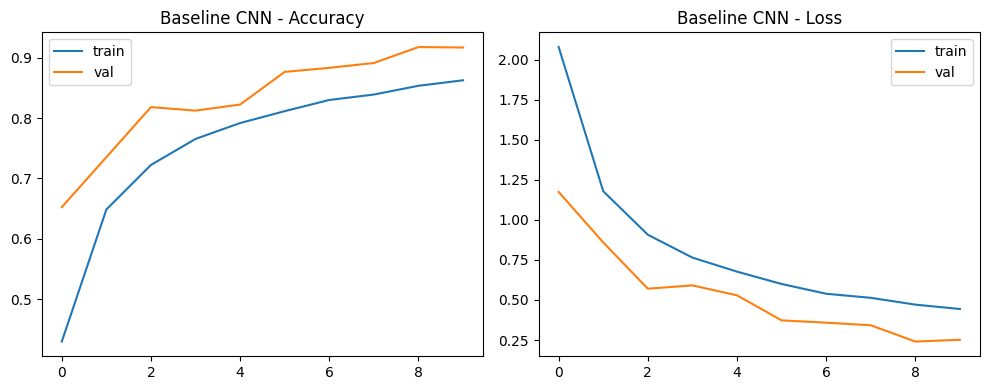

Baseline CNN -> Accuracy: 0.9174, F1-Score: 0.9162


(array([ 0,  0,  0, ..., 37, 37, 37], dtype=int32),
 array([ 0,  0, 19, ..., 37, 37, 37]))

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]

history_baseline = baseline_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen, callbacks=callbacks
)

plot_history(history_baseline, "Baseline CNN")
evaluate_model(baseline_model, "Baseline CNN")

# Improved CNN

In [ ]:
improved_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.3),

    Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.3),

    Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    layers.Activation('relu'),
    MaxPooling2D(),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

improved_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
improved_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │    13,107,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,211,366 (50.40 MB)

 Trainable params: 13,210,918 (50.40 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 425s 313ms/step - accuracy: 0.1519 - loss: 3.2793 - val_accuracy: 0.1839 - val_loss: 3.1660 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 352s 259ms/step - accuracy: 0.1555 - loss: 3.1409 - val_accuracy: 0.1939 - val_loss: 3.0724 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 323s 238ms/step - accuracy: 0.1715 - loss: 3.0343 - val_accuracy: 0.2562 - val_loss: 2.7292 - learning_rate: 2.0000e-04


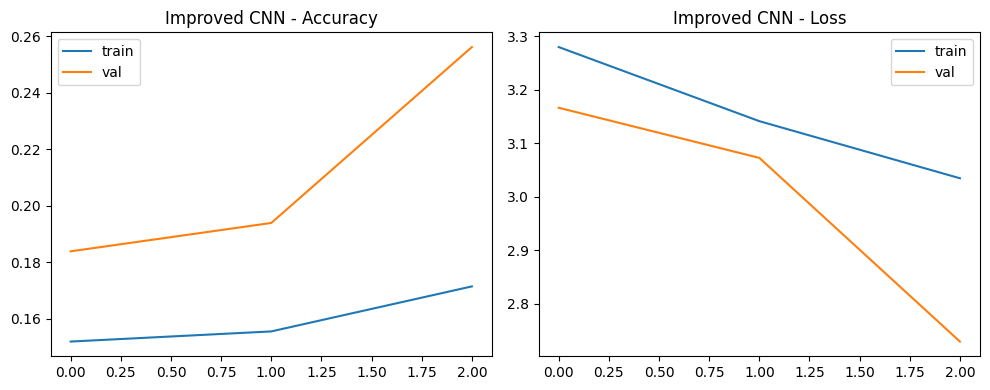

Improved CNN -> Accuracy: 0.1839, F1-Score: 0.0671


(array([ 0,  0,  0, ..., 37, 37, 37], dtype=int32),
 array([35, 35, 24, ..., 35, 35, 35]))

In [ ]:
history_improved = improved_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen, callbacks=callbacks
)

plot_history(history_improved, "Improved CNN")
evaluate_model(improved_model, "Improved CNN")

# Transfer Learning

In [ ]:
def build_transfer_model(base_class, preprocess_fn, name):
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.Lambda(lambda t: preprocess_fn(t * 255.0))(inputs)

    base_model = base_class(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name=name)
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model

### MobileNetV2

/tmp/ipykernel_603/1705303702.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = base_class(include_top=False, weights='imagenet', input_tensor=x)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 346s 241ms/step - accuracy: 0.7590 - loss: 0.7999 - val_accuracy: 0.8828 - val_loss: 0.3533 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 305s 224ms/step - accuracy: 0.8472 - loss: 0.4822 - val_accuracy: 0.9069 - val_loss: 0.2704 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 313s 231ms/step - accuracy: 0.8882 - loss: 0.3414 - val_accuracy: 0.9205 - val_loss: 0.2384 - learning_rate: 2.0000e-04
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 311s 229ms/step - accuracy: 0.8953 - loss: 0.3219 - val_accuracy: 0.9224 - val_loss: 0.2279 - learning_rate: 2.0000e-04
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 311s 229ms/step - accuracy: 0.9006 - loss: 0.3025 - val_accuracy: 0.9203 - val_loss: 0.2343 - learning_rate: 2.0000e-04
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 307s 226ms/step - accuracy: 0.9032 - loss: 0.2952 - val_accuracy: 0.9267 - val_loss: 0.2188 - learning_rate

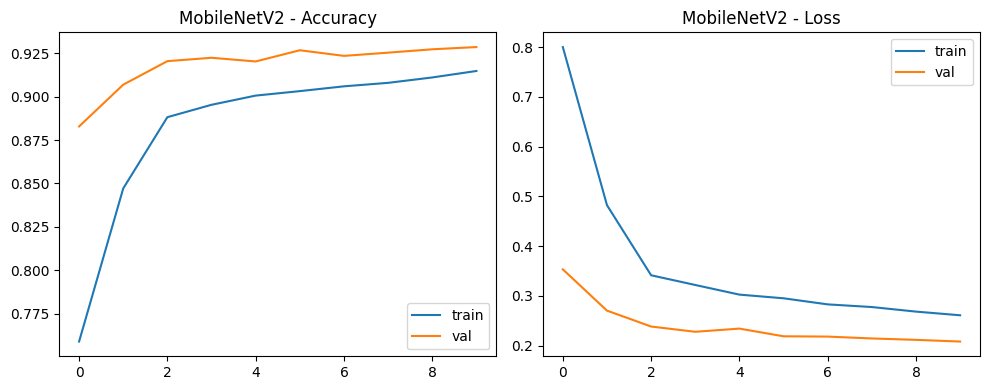

MobileNetV2 -> Accuracy: 0.9286, F1-Score: 0.9276


(array([ 0,  0,  0, ..., 37, 37, 37], dtype=int32),
 array([ 0,  0, 11, ..., 37, 37, 37]))

In [ ]:
mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2, mobilenet_preprocess, "MobileNetV2")

history_mobilenet = mobilenet_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen, callbacks=callbacks
)

plot_history(history_mobilenet, "MobileNetV2")
evaluate_model(mobilenet_model, "MobileNetV2")

### ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 367s 261ms/step - accuracy: 0.7963 - loss: 0.6892 - val_accuracy: 0.9217 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 361s 266ms/step - accuracy: 0.8824 - loss: 0.3617 - val_accuracy: 0.9275 - val_loss: 0.2221 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 347s 255ms/step - accuracy: 0.9234 - loss: 0.2319 - val_accuracy: 0.9444 - val_loss: 0.1665 - learning_rate: 2.0000e-04


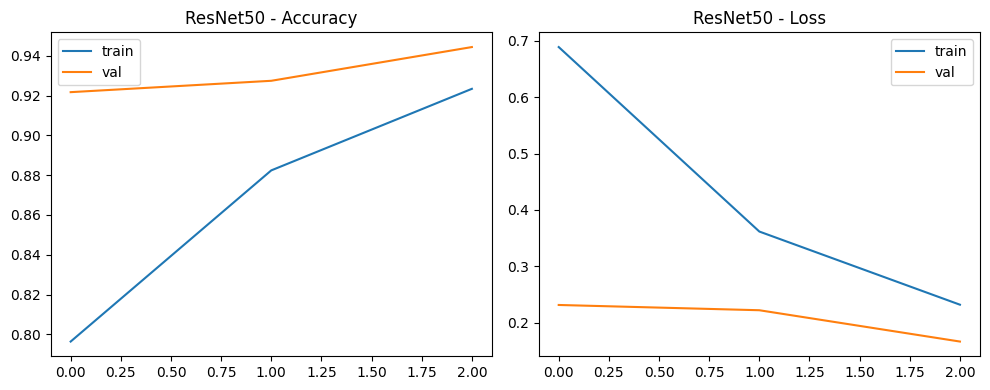

ResNet50 -> Accuracy: 0.9217, F1-Score: 0.9199


(array([ 0,  0,  0, ..., 37, 37, 37], dtype=int32),
 array([ 0,  0,  0, ..., 37, 37, 37]))

In [ ]:
resnet_model, resnet_base = build_transfer_model(ResNet50, resnet_preprocess, "ResNet50")

history_resnet = resnet_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen, callbacks=callbacks
)

plot_history(history_resnet, "ResNet50")
evaluate_model(resnet_model, "ResNet50")

### EfficientNetB0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 357s 244ms/step - accuracy: 0.8081 - loss: 0.6321 - val_accuracy: 0.9206 - val_loss: 0.2501 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 322s 237ms/step - accuracy: 0.8924 - loss: 0.3285 - val_accuracy: 0.9325 - val_loss: 0.2058 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 316s 233ms/step - accuracy: 0.9075 - loss: 0.2777 - val_accuracy: 0.9304 - val_loss: 0.2078 - learning_rate: 0.0010
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 328s 241ms/step - accuracy: 0.9143 - loss: 0.2531 - val_accuracy: 0.9407 - val_loss: 0.1783 - learning_rate: 0.0010
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 319s 235ms/step - accuracy: 0.9195 - loss: 0.2359 - val_accuracy: 0.9462 - val_loss: 0.1606 - learning_rate: 0.0010
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 319s 235ms/step - accuracy: 0.9221 - loss: 0.2286 - val_accuracy: 0.9501 - val_loss: 0.1540 - learning_rate: 0.0010
E

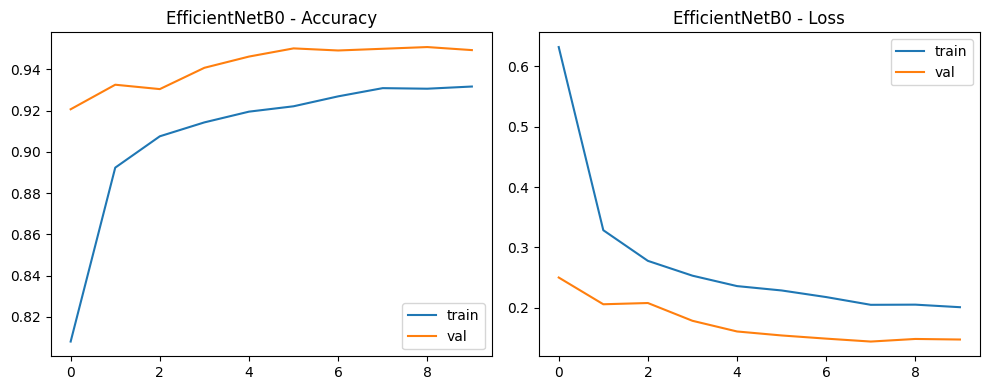

EfficientNetB0 -> Accuracy: 0.9499, F1-Score: 0.9496


(array([ 0,  0,  0, ..., 37, 37, 37], dtype=int32),
 array([ 0,  0, 14, ..., 37, 24, 37]))

In [ ]:
effnet_model, effnet_base = build_transfer_model(EfficientNetB0, efficientnet_preprocess, "EfficientNetB0")

history_effnet = effnet_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen, callbacks=callbacks
)

plot_history(history_effnet, "EfficientNetB0")
evaluate_model(effnet_model, "EfficientNetB0")

### EfficientNetB0 Fine Tune

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 358s 241ms/step - accuracy: 0.8299 - loss: 0.6465 - val_accuracy: 0.9232 - val_loss: 0.2415 - learning_rate: 1.0000e-05
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 317s 233ms/step - accuracy: 0.8943 - loss: 0.3502 - val_accuracy: 0.9377 - val_loss: 0.1885 - learning_rate: 1.0000e-05
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 319s 235ms/step - accuracy: 0.9093 - loss: 0.2883 - val_accuracy: 0.9410 - val_loss: 0.1811 - learning_rate: 2.0000e-06


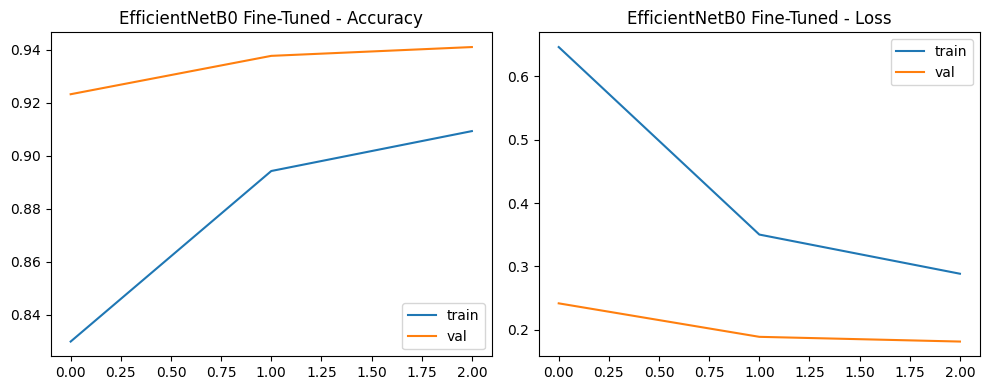

EfficientNetB0 Fine-Tuned -> Accuracy: 0.9232, F1-Score: 0.9232


In [ ]:
effnet_base.trainable = True
for layer in effnet_base.layers[:-30]:
    layer.trainable = False

effnet_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_finetune = effnet_model.fit(
    train_gen, epochs=5, validation_data=val_gen, callbacks=callbacks
)

plot_history(history_finetune, "EfficientNetB0 Fine-Tuned")
y_true, y_pred = evaluate_model(effnet_model, "EfficientNetB0 Fine-Tuned")

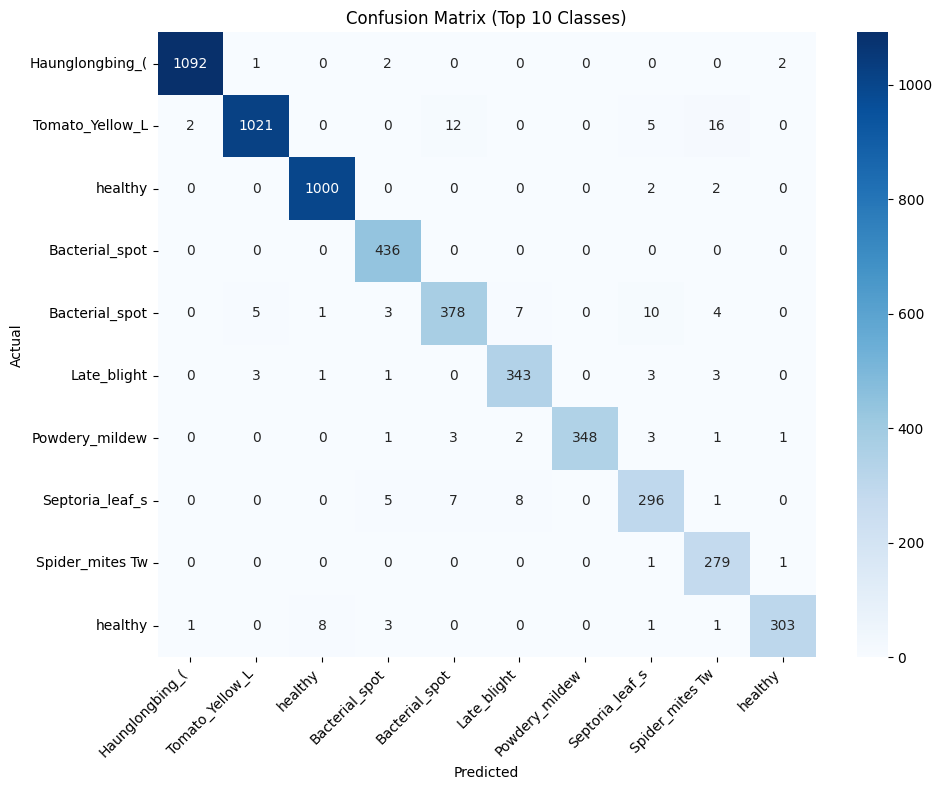

In [ ]:
top_classes = counts_df.sort_values("Count", ascending=False).head(10)["Class"].tolist()
top_idx = [class_indices[c] for c in top_classes]
mask = np.isin(y_true, top_idx)

cm_vals = confusion_matrix(y_true[mask], y_pred[mask], labels=top_idx)
labels = [index_to_class[i].split("___")[-1][:15] for i in top_idx]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_vals, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Top 10 Classes)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Grad-CAM Explainability

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(model.inputs, [model.get_layer(last_conv_layer_name).output, model.output])

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

In [ ]:
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

In [ ]:
last_conv_layer = get_last_conv_layer(effnet_model)

In [ ]:
def show_gradcam(img_path, model, last_conv_layer_name):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    heatmap, pred_index = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
    predicted_class = index_to_class[pred_index]

    heatmap_resized = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_resized]
    jet_heatmap = Image.fromarray(np.uint8(jet_heatmap * 255)).resize((IMG_SIZE, IMG_SIZE))
    overlay = np.array(jet_heatmap) * 0.4 + np.array(img)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Heatmap")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(f"Predicted: {predicted_class.split('___')[-1]}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_210']
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)
/tmp/ipykernel_603/3573823715.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


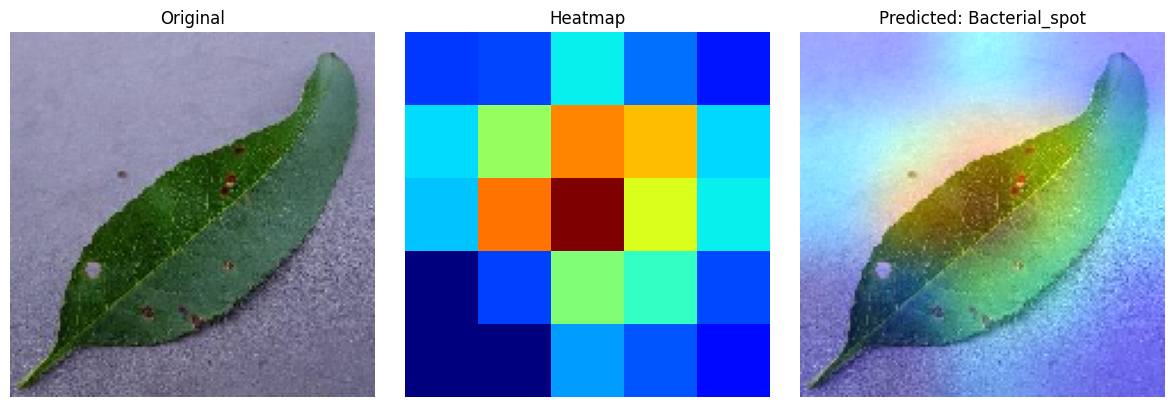

In [ ]:
sample_class = random.choice(CLASS_NAMES)
sample_img_name = random.choice(os.listdir(os.path.join(DATA_DIR, sample_class)))
sample_path = os.path.join(DATA_DIR, sample_class, sample_img_name)

show_gradcam(sample_path, effnet_model, last_conv_layer)

/tmp/ipykernel_603/3573823715.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


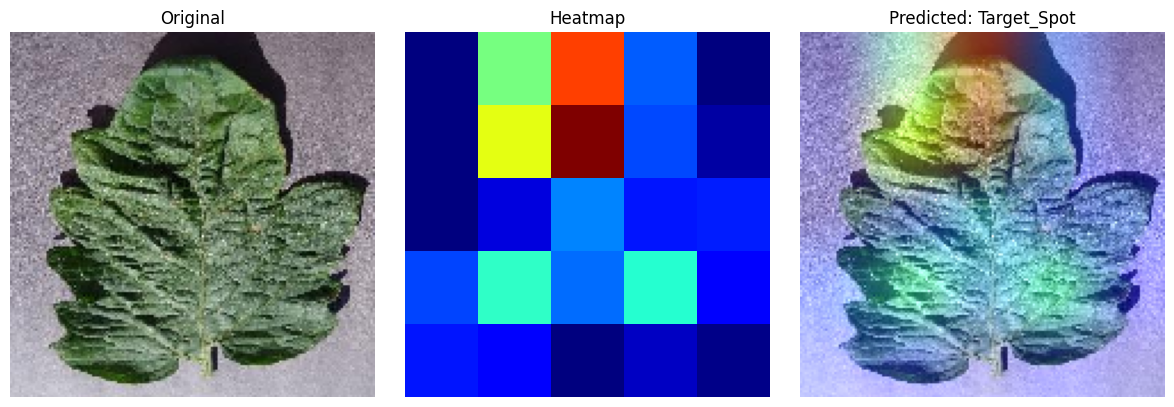

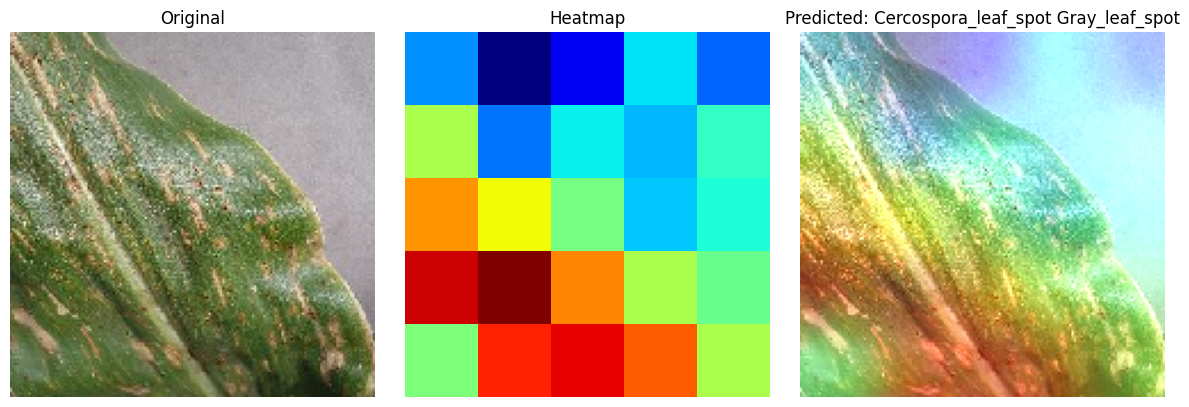

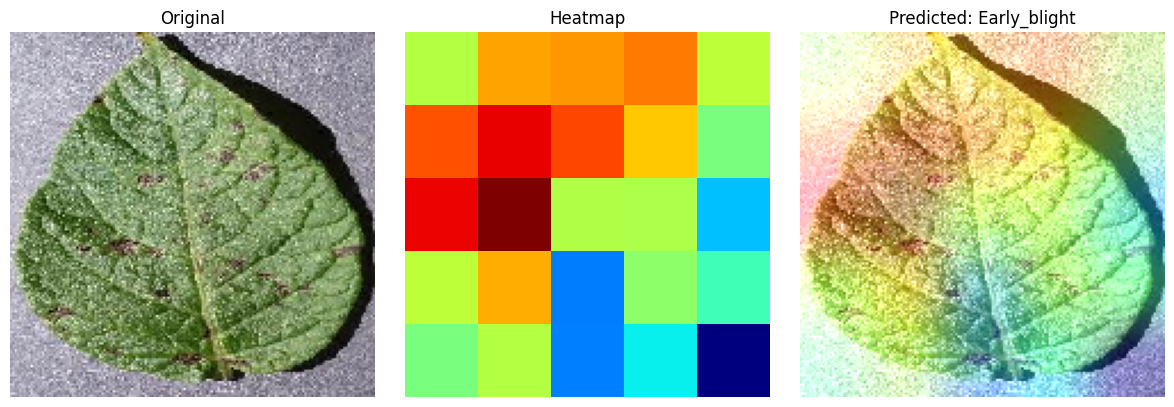

In [ ]:
for _ in range(3):
    cls = random.choice(CLASS_NAMES)
    img_name = random.choice(os.listdir(os.path.join(DATA_DIR, cls)))
    path = os.path.join(DATA_DIR, cls, img_name)
    show_gradcam(path, effnet_model, last_conv_layer)

# Model Comparison

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values("Accuracy", ascending=False)
print(comparison_df)

                           Accuracy  Precision    Recall  F1-Score
EfficientNetB0             0.949949   0.951705  0.949949  0.949626
MobileNetV2                0.928565   0.930039  0.928565  0.927646
EfficientNetB0 Fine-Tuned  0.923219   0.926843  0.923219  0.923210
ResNet50                   0.921744   0.927265  0.921744  0.919866
Baseline CNN               0.917412   0.920733  0.917412  0.916238
Improved CNN               0.183888   0.042140  0.183888  0.067058


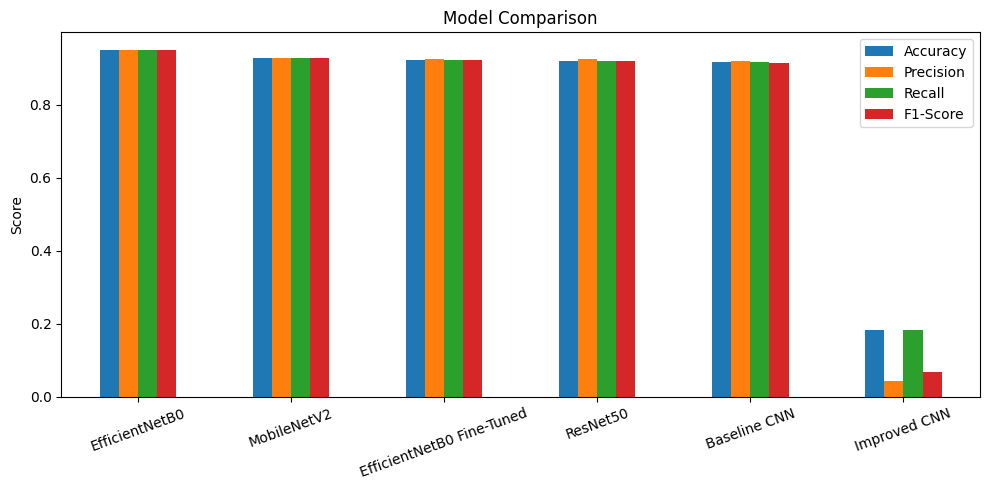

In [ ]:
comparison_df.plot(kind='bar', figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Save the best model

In [ ]:
effnet_model.save("/content/plantvillage/plant_disease_model.keras")

In [ ]:
import json

with open("/content/plantvillage/class_indices.json", "w") as f:
    json.dump(index_to_class, f)

from google.colab import files
files.download("/content/plantvillage/plant_disease_model.keras")
files.download("/content/plantvillage/class_indices.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>